<a href="https://colab.research.google.com/github/flipiwolker-alt/cv-video-analytics/blob/main/pz_2_normal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ПЗ 2 — Нарезка видео на изображения

**Задача:** загрузить видеофайл, нарезать на отдельные кадры с заданным шагом, сохранить в папку `outputs/frames/`.

In [2]:
!pip install opencv-python-headless moviepy yt-dlp -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 86.7 MB/s eta 0:00:00


In [3]:
import os
import cv2
from IPython.display import Image, display

OUTPUT_DIR = '/content/outputs/frames'
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [4]:
# Вариант 1: загрузить свой файл
from google.colab import files
uploaded = files.upload()
video_path = list(uploaded.keys())[0]

KeyboardInterrupt: 

In [5]:

!yt-dlp -f worst -o '/tmp/test_video.mp4' 'https://www.youtube.com/watch?v=dQw4w9WgXcQ'
video_path = '/tmp/test_video.mp4'

[youtube] Extracting URL: https://www.youtube.com/watch?v=dQw4w9WgXcQ
[youtube] dQw4w9WgXcQ: Downloading webpage
[youtube] dQw4w9WgXcQ: Downloading android vr player API JSON
[info] dQw4w9WgXcQ: Downloading 1 format(s): 18
[download] Destination: /tmp/test_video.mp4
[download] 100% of   11.28MiB in 00:00:00 at 41.85MiB/s


In [6]:
FRAME_STEP = 30  # сохранять каждый N-й кадр

cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f'FPS: {fps:.1f} | Кадров всего: {total} | Длительность: {total/fps:.1f} сек')

frame_idx = 0
saved = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    if frame_idx % FRAME_STEP == 0:
        out_path = os.path.join(OUTPUT_DIR, f'frame_{frame_idx:06d}.jpg')
        cv2.imwrite(out_path, frame)
        saved += 1
    frame_idx += 1
cap.release()
print(f'Сохранено кадров: {saved}')

FPS: 25.0 | Кадров всего: 5326 | Длительность: 213.0 сек
Сохранено кадров: 178


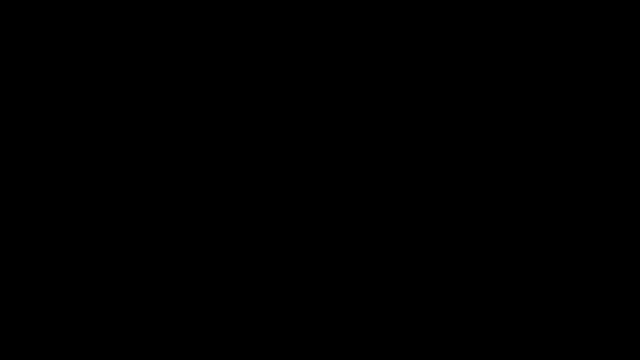

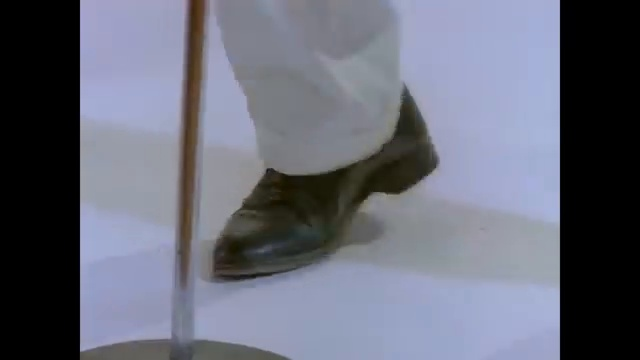

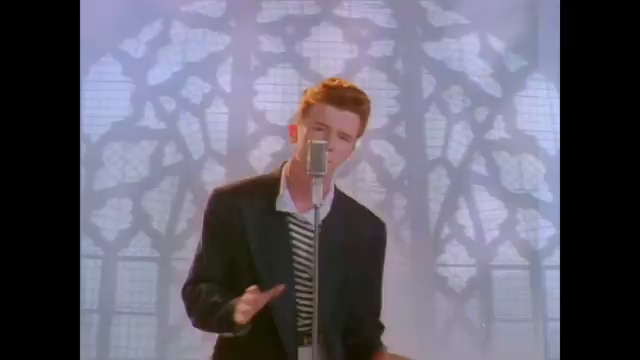

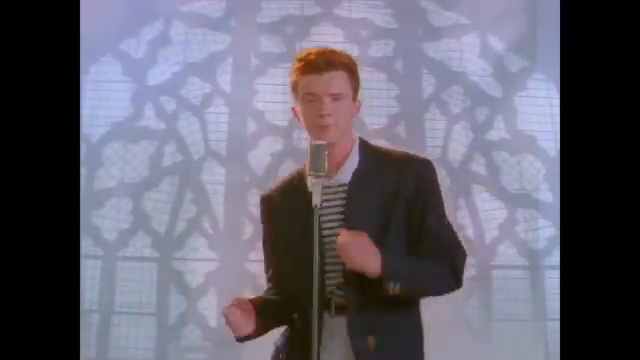

In [7]:
# Показать первые 4 кадра
frames = sorted(os.listdir(OUTPUT_DIR))[:4]
for f in frames:
    display(Image(filename=os.path.join(OUTPUT_DIR, f), width=400))

In [9]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copytree('/content/outputs/frames',
                 '/content/drive/MyDrive/cv-frames',
                 dirs_exist_ok=True)
print('Кадры сохранены в Drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Кадры сохранены в Drive
